In [11]:
from datasets import load_dataset

ds = load_dataset("json", data_files="/data2/seohyeong/instruction-ref/results/arena10-refined-yeval.jsonl", split="train")

In [12]:
import numpy as np

# score 컬럼의 평균과 분산 계산 후 새로운 컬럼으로 저장
ds = ds.map(lambda x: {
    **x,
    "score_mean": np.mean(x["similarity_scores"]),
    "score_variance": np.var(x["similarity_scores"])
})

In [13]:
df = ds.to_pandas()
df.head()

,instruction,responses,similarity_scores,avg_similarity_score,score_mean,score_variance
0,Determine the time in hours and minutes when t...,[To determine the time it takes for the second...,"[0.07275390625, 0.07373046875]",0.073242,0.073242,2.384186e-07
1,Develop a connector to automate the sending of...,[Thank you for providing the task to develop a...,"[0.10791015625, 0.10546875]",0.106689,0.106689,1.490116e-06
2,Retrieve the current weather and summarize the...,[I do not have access to real-time data. Howev...,"[0.12255859375, 0.103515625]",0.113037,0.113037,9.065866e-05
3,Identify if a married person is observing an u...,"[Given the information provided, it cannot be ...","[0.1357421875, 0.126953125]",0.131348,0.131348,1.931190e-05
4,List and analyze the moves up to the Queen’s G...,[Moves:\n\n1. e4 (Queen's Gambit)\n2. d4 (Cent...,"[0.08935546875, 0.07958984375]",0.084473,0.084473,2.384186e-05


/tmp/ipykernel_2277393/478240571.py:19: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = plt.gca()
/tmp/ipykernel_2277393/478240571.py:26: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter1 = ax.scatter(


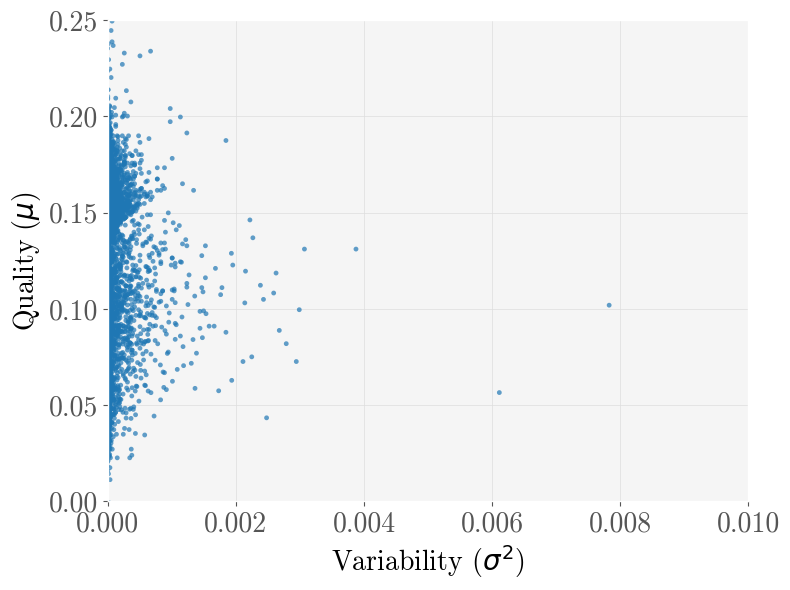

In [14]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import seaborn as sns

# 🔹 1. 커스텀 컬러맵 정의
custom_cmap = LinearSegmentedColormap.from_list(
    "custom_palette", ["#6a0dad", "#20639B", "#3CAEA3", "#F6D55C"], N=256
)

# 🔹 2. 스타일 적용
plt.style.use("ggplot")
plt.rcParams['font.family'] = 'cmr10'
plt.rcParams["axes.unicode_minus"] = False

# 🔹 3. 플롯 생성
light_gray = "#f5f5f5"
plt.figure(figsize=(8, 6))  # 전체 배경색 설정
ax = plt.gca()
ax.set_facecolor(light_gray)  # 그래프 내부 배경색 설정

palette = sns.color_palette("tab10", n_colors=3)

combined_df_sample = df
ax.set_facecolor("#f5f5f5")
scatter1 = ax.scatter(
    combined_df_sample['score_variance'], 
    combined_df_sample['score_mean'], 
    c=palette[0],  
    s=12, 
    edgecolors='none', 
    alpha=0.7
)

ax.set_ylabel('Quality ($\mu$)', fontsize=20, fontweight='bold', color='black')
ax.set_xlabel('Variability ($\sigma^2$)', fontsize=20, fontweight='bold', color='black')
ax.set_ylim(bottom=0, top=0.25)
ax.set_xlim(left=0, right=0.01)
ax.grid(True, linestyle='-', linewidth=0.5, alpha=1, color='#dddddd')
ax.tick_params(axis='both', labelsize=20)  # X, Y축 숫자 크기 증가

# bb = lambda c: dict(boxstyle="round,pad=0.3", ec=c, lw=2, fc="white")
# an1 = ax.annotate("High Variance", xy=(0.8, 0.40), xycoords="axes fraction", fontsize=20, color='black',
#              va="center", ha="center", bbox=bb('grey'))
# an2 = ax.annotate("High Average", xy=(0.25, 0.90), xycoords="axes fraction", fontsize=20, color='black',
#              va="center", ha="center", bbox=bb('grey'))
# an3 = ax.annotate("Low Average", xy=(0.30, 0.15), xycoords="axes fraction", fontsize=20, color='black',
#              va="center", ha="center", bbox=bb('grey'))


# 레이아웃 조정 및 출력
plt.tight_layout()

# 그래프 출력
plt.savefig("scatter_plot_comb.png", dpi=300, bbox_inches='tight', facecolor='w')
plt.savefig("scatter_plot_comb.pdf", dpi=300, bbox_inches='tight', facecolor='w')

plt.show()

In [15]:
# score_mean의 평균 계산 및 출력
mean_score_mean = combined_df_sample['score_mean'].mean()
print(f"score_mean 평균: {mean_score_mean:.6f}")

score_mean 평균: 0.132601
